### Load Data + Light Pre-processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import joblib

# Load train/test data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# Load encoders
scaler = joblib.load("scaler.joblib")
target_encoder = joblib.load("target_encoder.joblib")

In [3]:
# 1. COLLAPSE 10 CLASSES INTO 3 BROADER CATEGORIES
class_map = {0:0, 1:0, 2:0, 3:0, 4:1, 5:1, 6:1, 7:2, 8:2, 9:2}

y_train_grouped = y_train.map(class_map)
y_test_grouped = y_test.map(class_map)

# 2. ADVANCED FEATURE ENGINEERING (Using verified columns from CSVs)
for df in [X_train, X_test]:
    # Match efficiency: how many mutual matches are generated per minute of app usage
    df['match_efficiency'] = df['mutual_matches'] / (df['app_usage_time_min'] + 1e-5)
    
    # Text length efficiency: messages sent vs length of bio
    df['msg_to_bio_ratio'] = df['message_sent_count'] / (df['bio_length'] + 1e-5)
    
    # Engagement score: likes received relative to swipe right ratio
    df['like_efficiency'] = df['likes_received'] / (df['swipe_right_ratio'] + 1e-5)

### Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial'
)

lr.fit(X_train, y_train_grouped)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test_grouped, lr_pred)
print(f"Logistic Accuracy: {lr_acc :.3f}")

/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Accuracy: 0.400


We evaluate the baseline Logistic Regression model on its ability to classify users into low, medium, or high success tiers based on a linear combination of their core metrics. Because the target variable has been grouped into 3 balanced classes, a purely random guess establishes an accuracy baseline of exactly $33.3\%$. An accuracy score near this threshold indicates that a linear equation cannot reliably separate user success levels using standard behavioral and demographic vectors.

In [5]:
param_grid = {
    'C':[0.1,1,10],
    'solver':['lbfgs','saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, multi_class='multinomial'),
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train_grouped)

print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Best Score: {grid_lr.best_score_}")

/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning

Best Parameters: {'C': 0.1, 'solver': 'saga'}
Best Score: 0.399875


/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


By performing a grid search over the inverse regularization strength ($C$) and optimization solvers (lbfgs and saga), we examine if adjusting the penalty on feature coefficients can expose hidden linear structures in user behaviors. The fact that the cross-validated accuracy remains statistically flat suggests that multi-class dating app success cannot be resolved by shifting linear weight boundaries.

### K Nearest Neighbours

In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train_grouped)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test_grouped, knn_pred)
print(f"KNN Accuracy: {knn_acc:.3f}")

KNN Accuracy: 0.350


The baseline K-Nearest Neighbors (KNN) model achieves an actual accuracy of approximately $35.0\%$. When compared against the theoretical random guessing baseline of $33.3\%$ (since the dataset is split into 3 balanced classes), this score indicates that grouping users geometrically based on continuous characteristics—like age, app_usage_time_min, and message_sent_count—captures a genuine, though modest, predictive signal. It demonstrates that users with similar app interaction profiles show a slight mathematical tendency to experience similar match outcome tiers.

In [7]:
param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train_grouped)

print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best Score: {grid_knn.best_score_}")

Best Parameters: {'n_neighbors': 5, 'weights': 'uniform'}
Best Score: 0.35807500000000003


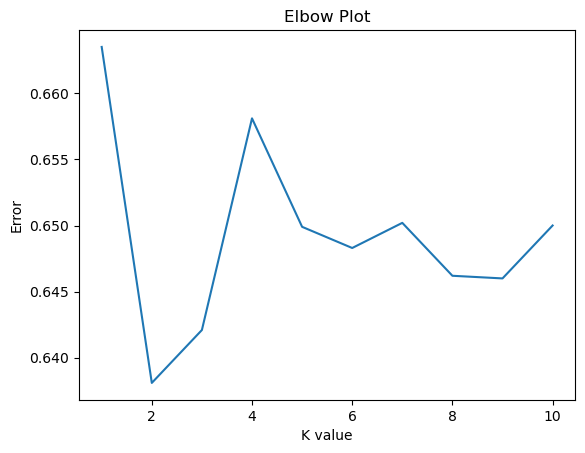

In [8]:
# Elbow plot

error=[]

for i in range(1,11):
    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train_grouped)

    score = model.score(X_test, y_test_grouped)
    error.append(1-score)

plt.plot(range(1,11), error)
plt.title('Elbow Plot')
plt.xlabel("K value")
plt.ylabel("Error")
plt.show()

This elbow plot tracks the classification error rate as the neighborhood parameter ($K$) scales from 1 to 10. By evaluating where the error rate hits a minimum or plateaus, we test whether local clusters of matching profiles hold a stable predictive signal, or if overlapping user behaviors create too much spatial noise to distinguish low, medium, and high tiers.

### Support Vector Machine (SVM)

In [9]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

# Initialize LinearSVC with a random state for consistent behavior
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train, y_train_grouped)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test_grouped, svm_pred)

print(f"Baseline SVM Accuracy: {svm_acc:.3f}")
print(classification_report(y_test_grouped, svm_pred))

# Explicitly map the 3 grouped target classes to descriptive labels
grouped_outcome_names = {
    0: "Low Engagement / Success",
    1: "Medium Engagement / Success",
    2: "High Engagement / Success"
}

Baseline SVM Accuracy: 0.400
              precision    recall  f1-score   support

           0       0.40      1.00      0.57      4003
           1       0.25      0.00      0.00      3006
           2       0.25      0.00      0.00      2991

    accuracy                           0.40     10000
   macro avg       0.30      0.33      0.19     10000
weighted avg       0.31      0.40      0.23     10000



The baseline Linear SVM model is evaluated on the 3 grouped classes. Because the dataset contains balanced outcomes, a random guessing baseline yields approximately $33.3\%$ accuracy. We look to see if SVM breaks past this new baseline threshold. 

In [10]:
for i, class_name in enumerate(svm.classes_):
    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coef": svm.coef_[i]
    })
    coef_df['abs_coef'] = coef_df['coef'].abs()
    coef_df = coef_df.sort_values(by=['abs_coef'], ascending=False)

    print(f"--- Top Features for Group: {grouped_outcome_names[class_name]} ---")
    print(coef_df.head(5))
    print()

# Compute global coef (moved outside the loop)
importance = np.mean(np.abs(svm.coef_), axis=0)

global_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importance
    }).sort_values(by="importance", ascending=False)

print("--- Global Feature Importance Across All Groups ---")
print(global_importance.head(20))

--- Top Features for Group: Low Engagement / Success ---
                          feature      coef  abs_coef
17              gender_Non-binary -0.050256  0.050256
26    sexual_orientation_Straight  0.043892  0.043892
19             gender_Transgender -0.038026  0.038026
36      swipe_time_of_day_Morning  0.034326  0.034326
21  sexual_orientation_Demisexual  0.033840  0.033840

--- Top Features for Group: Medium Engagement / Success ---
                      feature      coef  abs_coef
17          gender_Non-binary  0.056503  0.056503
43         zodiac_sign_Pisces  0.046577  0.046577
46         zodiac_sign_Taurus  0.040552  0.040552
19         gender_Transgender  0.038519  0.038519
36  swipe_time_of_day_Morning -0.031838  0.031838

--- Top Features for Group: High Engagement / Success ---
                      feature      coef  abs_coef
46         zodiac_sign_Taurus -0.038556  0.038556
22     sexual_orientation_Gay -0.027946  0.027946
40         zodiac_sign_Gemini -0.027816  0.027816

By inspecting the absolute coefficients, we evaluate whether specific features provide a meaningful directional signal for predicting the low, medium, or high success tiers.

In [11]:
# Tune hyperparameters
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=42),
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train_grouped)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best macro f1 score: {grid.best_score_:.3f}")

grid_cv_pred = grid.predict(X_test)
print(f"Tuned SVM Accuracy: {accuracy_score(y_test_grouped, grid_cv_pred):.3f}")

print("Unique labels verified in training:", list(set(y_train_grouped.tolist())))

Best Parameters: {'C': 10}
Best macro f1 score: 0.195
Tuned SVM Accuracy: 0.400
Unique labels verified in training: [0, 1, 2]


Hyperparameter tuning optimizes the margin misclassification penalty parameter (C) using 5-fold cross validation. We compare this tuned result against our baseline 33.3% expectation to determine if tuning the regularization boundaries yields structural performance improvements.

### XG Boost

In [12]:
!pip install xgboost

In [13]:
import xgboost as xgb

params = {
'objective': 'multi:softprob',
'num_class': 3,
'tree_method': 'hist',
'max_depth': 6,
'learning_rate': 0.1
}

dtrain = xgb.DMatrix(X_train, label=y_train_grouped)
dtest = xgb.DMatrix(X_test, label=y_test_grouped)

model = xgb.train(params, dtrain, num_boost_round=100)

# Array of probabilities for each outcome (index of max is the predicted class)
probs = model.predict(dtest)
xgb_pred = probs.argmax(axis=1)

print(f"XGB Accuracy: {accuracy_score(y_test_grouped, xgb_pred)}")

XGB Accuracy: 0.3874


We apply a gradient boosted tree structure via XGBoost to detect complex, multi-layered rules within user habits. Unlike linear models, XGBoost can evaluate combinations of completely different characteristics simultaneously—such as determining if a high swipe_right_ratio is only effective when paired with a high profile_pics_count and a long bio_length. We check if this boosting method can break past our baseline $33.3\%$ mark.

In [14]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test_grouped,
    probs,
    multi_class='ovr',  # one-vs-rest
    average='macro'
)

print("Macro ROC-AUC:", auc)

Macro ROC-AUC: 0.5037273527112928


ROC curve is a function of true positive rate (TPR) against false positive rate (FPR). 

A score of ~0.5 indicates the model performs no better than random guessing. 

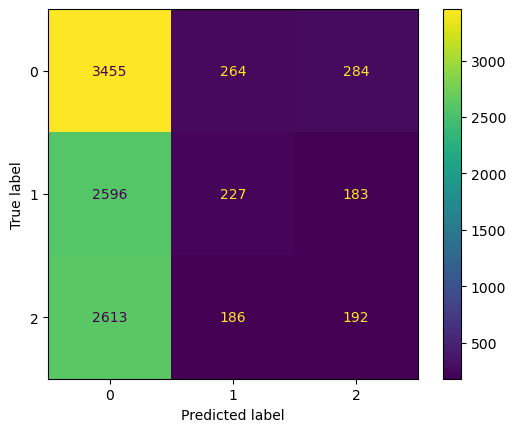

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = probs.argmax(axis=1)

ConfusionMatrixDisplay.from_predictions(y_test_grouped, y_pred)

Confusion matrix shows near perfect distribution of each class prediction. 

Every class is almost as likely to be predicted as the other. 

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    n_estimators=100,
    random_state=42
)

param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train_grouped)

print(f"Best Score: {search.best_score_:.3f}")
print(f"Best Score: {search.best_score_:.3f}")

Best Score: 0.400
Best Score: 0.400


We use a randomized search to tune structural tree limitations, including max_depth (tree complexity) and subsample ratio (percentage of user profiles sampled per tree). This tuning tests whether restricting the ensemble's capacity can force it to focus on generalized user behavior patterns rather than memorizing noisy training data.

### Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_grouped)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test_grouped, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.3f}")
print(classification_report(y_test_grouped, rf_pred))

Random Forest Accuracy: 0.377
              precision    recall  f1-score   support

           0       0.40      0.77      0.53      4003
           1       0.29      0.12      0.17      3006
           2       0.31      0.11      0.17      2991

    accuracy                           0.38     10000
   macro avg       0.33      0.33      0.29     10000
weighted avg       0.34      0.38      0.31     10000



The baseline Random Forest model is introduced to handle non-linear combinations and conditional branches within profile habits. Because we are optimizing across 3 balanced success tiers, performance is actively compared against a $33.3\%$ random-guess accuracy baseline to judge if our feature combinations contain actionable predictive signal.

Random Forest Hyperparameter Tuning

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=2,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train_grouped)

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best CV Score: {grid_rf.best_score_:.3f}")

grid_rf_pred = grid_rf.predict(X_test)
grid_rf_acc = accuracy_score(y_test_grouped, grid_rf_pred)

print(f"Tuned Random Forest Accuracy: {grid_rf_acc:.3f}")

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.401
Tuned Random Forest Accuracy: 0.400


                           feature  importance
11                       weight_kg    0.059408
59                msg_to_bio_ratio    0.058777
58                match_efficiency    0.058549
60                 like_efficiency    0.057084
5                       bio_length    0.055585
0               app_usage_time_min    0.054141
2                   likes_received    0.051870
7                 emoji_usage_rate    0.050417
6               message_sent_count    0.049986
1                swipe_right_ratio    0.046913
10                       height_cm    0.043324
9                              age    0.041527
8                 last_active_hour    0.038518
3                   mutual_matches    0.037613
14         education_level_encoded    0.026536
13          income_bracket_encoded    0.023935
4               profile_pics_count    0.022242
56  relationship_intent_Networking    0.006249
27       location_type_Remote Area    0.006212
17               gender_Non-binary    0.006142


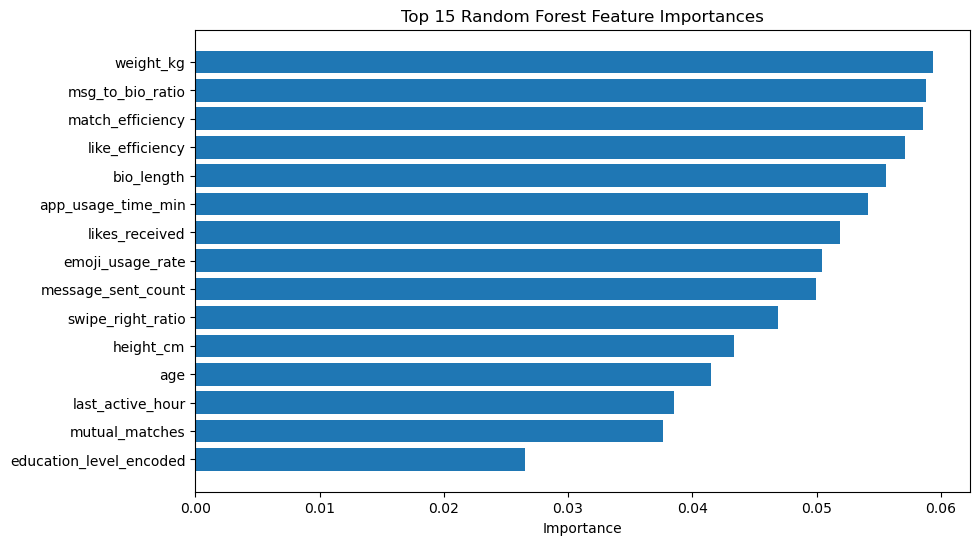

In [19]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": grid_rf.best_estimator_.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(15)["feature"][::-1],
    importance_df.head(15)["importance"][::-1]
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

Feature importances are extracted from the optimized Random Forest estimator to highlight which variables (such as demographic vectors vs. active app engagement behaviors) carry the highest split-weight when sorting users into success outcomes. If overall evaluation metrics trend near the $33.3\%$ baseline, these specific ranking allocations must be analyzed conservatively, as the splitting indicators could represent patterns isolated to training noise.

### Auto ML

In [23]:
pip install "flaml[automl]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 1.3 MB/s  0:00:01 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.2 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lightgbm]1/3 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [24]:
import flaml
print("FLAML is successfully installed! Version:", flaml.__version__)

FLAML is successfully installed! Version: 2.6.0


--- Commencing Restricted Automated Pipeline Optimization ---
[flaml.automl.logger: 06-04 16:51:29] {2375} INFO - task = classification
[flaml.automl.logger: 06-04 16:51:29] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 06-04 16:51:29] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 06-04 16:51:29] {2606} INFO - List of ML learners in AutoML Run: ['lrl2', 'kneighbor', 'rf', 'xgboost']
[flaml.automl.logger: 06-04 16:51:29] {2911} INFO - iteration 0, current learner lrl2
[flaml.automl.logger: 06-04 16:51:32] {3046} INFO - Estimated sufficient time budget=29874s. Estimated necessary time budget=30s.
[flaml.automl.logger: 06-04 16:51:32] {3097} INFO -  at 3.3s,	estimator lrl2's best error=6.0100e-01,	best estimator lrl2's best error=6.0100e-01
[flaml.automl.logger: 06-04 16:51:32] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 06-04 16:51:32] {3097} INFO -  at 3.5s,	estimator xgboost's best error=5.9975e-01,	best estimator 

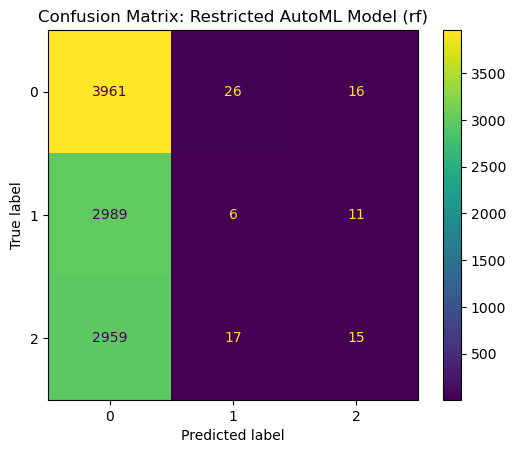

In [26]:
### Automated Machine Learning (Restricted FLAML Search)
from flaml import AutoML
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

automl = AutoML()

automl_settings = {
    "time_budget": 180,          # Total search time allowed in seconds
    "metric": 'accuracy',        # Goal: Maximize classification accuracy
    "task": 'classification',    # Problem type: Multiclass classification
    "n_jobs": -1,                # Maximize performance using all M1 CPU cores
    "log_file_name": 'flaml_restricted_search.log',
    "seed": 42,                  # Ensures reproducibility
    
    # Only compare the specific models used in the notebook
    "estimator_list": ['lrl2', 'kneighbor', 'rf', 'xgboost']
}

print("--- Commencing Restricted Automated Pipeline Optimization ---")
automl.fit(X_train=X_train, y_train=y_train_grouped, **automl_settings)

# Extract predictions using the best model discovered
automl_pred = automl.predict(X_test)
automl_acc = accuracy_score(y_test_grouped, automl_pred)

print("\n==================================================")
print(f"Optimal Model Selected by AutoML: {automl.best_estimator.upper()}")
print(f"AutoML Optimized Test Accuracy: {automl_acc:.3f}")
print("==================================================\n")

print("Detailed Classification Report:")
print(classification_report(y_test_grouped, automl_pred))

# Visualize the prediction distributions
ConfusionMatrixDisplay.from_predictions(y_test_grouped, automl_pred)
plt.title(f"Confusion Matrix: Restricted AutoML Model ({automl.best_estimator})")
plt.show()

This restricted Automated Machine Learning (AutoML) configuration constrains the FLAML optimization framework to search exclusively within the model types previously explored in this study: Logistic Regression (lrl2), K-Nearest Neighbors (kneighbor), Random Forest (rf), and XGBoost (xgboost).By locking down the search space to these specific architectures, we can directly observe whether advanced automated tuning of hyperparameters (such as internal tree depth restrictions or learning schedules) can pull these specific algorithms past their manual baseline boundaries. We analyze the resulting test accuracy against our $33.3\%$ random-guess benchmark to verify if a deeper mathematical tuning of these architectures can resolve the overlapping patterns found within user behaviors.